In [1]:
import rasterio
import numpy as np
import geopandas as gpd

In [6]:
niger = "/mnt/sdc/tree_density_and_coverage/tucker_tree_density_niger_v2.tif"
maradi = "/mnt/sdc/tree_density_and_coverage/tucker_tree_density_maradi_v2.tif"
zinder = "/mnt/sdc/tree_density_and_coverage/tucker_tree_density_zinder_v2.tif"
sahel = "/mnt/sdc/tree_density_and_coverage/tucker_tree_density_potapov_2020_v2.tif"

In [7]:
niger_rst = rasterio.open(niger).read(1)
maradi_rst = rasterio.open(maradi).read(1)
zinder_rst = rasterio.open(zinder).read(1)
sahel_rst = rasterio.open(sahel).read(1)

In [8]:
niger_rst = np.nan_to_num(niger_rst)
maradi_rst = np.nan_to_num(maradi_rst)
zinder_rst = np.nan_to_num(zinder_rst)
sahel_rst = np.nan_to_num(sahel_rst)

In [9]:
niger_rst = np.where(niger_rst < 0, 0, niger_rst)
maradi_rst = np.where(maradi_rst < 0, 0, maradi_rst)
zinder_rst = np.where(zinder_rst < 0, 0, zinder_rst)
sahel_rst = np.where(sahel_rst < 0, 0, sahel_rst)

In [10]:
print(niger_rst.sum(), maradi_rst.sum(), zinder_rst.sum(), sahel_rst.sum())

122530340.0 43240856.0 42310356.0 1196675800.0


In [2]:
shape = gpd.read_file("/mnt/sdc/tree_density_and_coverage/shapefiles/drylands/sahel_farmlad_trees.gpkg")
shape.head()

,OBJECTID,ISO,NAME_0,Continent,REgion,_count,_sum,_mean,geometry
0,1,AGO,Angola,Africa,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((1302793.772 -1863649.995, 1302..."
1,2,ATF,French Southern Territories,Africa,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((7653493.563 -6393286.956, 7653..."
2,3,BDI,Burundi,Africa,Eastern_Africa,NaN,NaN,NaN,"MULTIPOLYGON (((3385395.346 -257286.134, 33854..."
3,4,BEN,Benin,Africa,NaN,1805054.0,53363003.0,29.563106,"MULTIPOLYGON (((207162.461 701563.736, 207131...."
4,5,BFA,Burkina Faso,Africa,NaN,4156274.0,100866802.0,24.268564,"MULTIPOLYGON (((-50725.397 1698516.238, -49209..."


In [3]:
import matplotlib.pyplot as plt


In [4]:
# remove the rows with NaN values in sum column
shape = shape[~shape['_sum'].isna()]
shape = shape[~shape.isna()]
# sort by sum column
shape = shape.sort_values(by='_sum', ascending=False)
shape.head()

,OBJECTID,ISO,NAME_0,Continent,REgion,_count,_sum,_mean,geometry
38,39,NGA,Nigeria,Africa,NaN,20540533.0,355096629.0,17.287605,"MULTIPOLYGON (((652873.341 494149.259, 652780...."
41,42,SDN,Sudan,Africa,Eastern_Africa,12523897.0,144529452.0,11.540294,"MULTIPOLYGON (((4261727.403 2069680.623, 42617..."
30,31,MLI,Mali,Africa,NaN,5890954.0,138313943.0,23.479040,"MULTIPOLYGON (((-556597.348 2875498.872, -5565..."
37,38,NER,Niger,Africa,NaN,7710600.0,122673973.0,15.909783,"MULTIPOLYGON (((1333956.723 2695295.748, 13358..."
4,5,BFA,Burkina Faso,Africa,NaN,4156274.0,100866802.0,24.268564,"MULTIPOLYGON (((-50725.397 1698516.238, -49209..."


In [5]:
shape.sum()

/tmp/ipykernel_1790142/2828617428.py:1: FutureWarning: The default value of numeric_only in GeoDataFrame.sum is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  shape.sum()


OBJECTID                                                   688
ISO          NGASDNMLINERBFAETHTCDBENSENGHACMRCIVTGOGINERIC...
NAME_0       NigeriaSudanMaliNigerBurkina FasoEthiopiaChadB...
Continent    AfricaAfricaAfricaAfricaAfricaAfricaAfricaAfri...
_count                                              67597224.0
_sum                                              1188656514.0
_mean                                               458.202855
dtype: object

/home/rene1337/.local/lib/python3.10/site-packages/pandas/plotting/_matplotlib/core.py:807: UserWarning: The label '_sum' of <BarContainer object of 26 artists> starts with '_'. It is thus excluded from the legend.
  ax.legend(handles, labels, loc="best", title=title)


Text(0, 0.5, 'count')

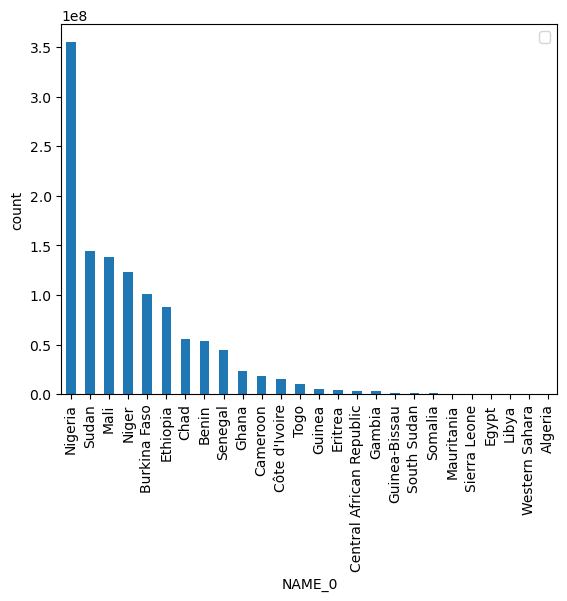

In [28]:
shape.plot(kind='bar', y="_sum", x="NAME_0")
plt.ylabel("count")